In [8]:
#관련 패키지 설치
!pip install datasets

zsh:1: /Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/bin/pip: bad interpreter: /Users/igyeongseob/Develop/ai/vector/venv/bin/python3: no such file or directory

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/igyeongseob/.pyenv/versions/3.12.6/bin/python3.12 -m pip install --upgrade pip


In [9]:
#관련 라이브러리 import
from datasets import load_dataset
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

In [11]:
dataset = load_dataset("keremberke/shoe-classification", "default", revision="refs/convert/parquet")
dataset = dataset["train"]


full/train/0000.parquet:   0%|          | 0.00/5.19M [00:00<?, ?B/s]

mini/train/0000.parquet:   0%|          | 0.00/21.5k [00:00<?, ?B/s]

full/validation/0000.parquet:   0%|          | 0.00/1.55M [00:00<?, ?B/s]

full/test/0000.parquet:   0%|          | 0.00/777k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [12]:
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 578
})

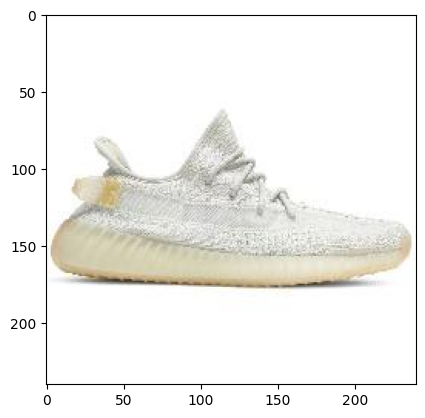

In [13]:
query_image = dataset[44]['image']
plt.imshow(query_image)
plt.show()

In [14]:
type(query_image)

PIL.JpegImagePlugin.JpegImageFile

In [15]:
query_image = np.array(query_image)

In [16]:
query_image.shape

(240, 240, 3)

In [17]:
img_vector = query_image.reshape(1, -1, 3)
img_vector.shape

(1, 57600, 3)

In [19]:
#변환된 벡터로부터 각 채널별(RGB) 벡터 추출
red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]

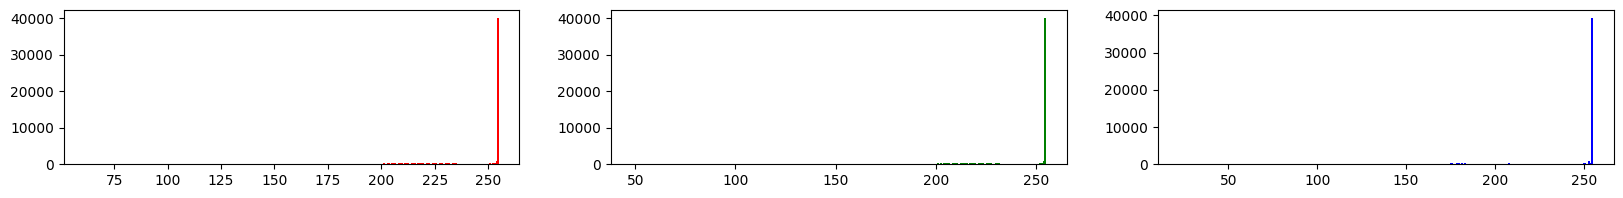

In [20]:
#히스토그램으로 나타내기
fig, axs = plt.subplots(1, 3, figsize=(20,2))
axs[0].hist(red_channel, bins=255, color='r')
axs[1].hist(green_channel, bins=255, color='g')
axs[2].hist(blue_channel, bins=255, color='b')
plt.show()

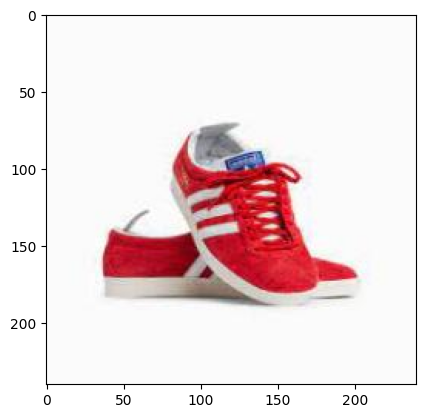

In [25]:
#다른 이미지
query_image = dataset[153]['image']
plt.imshow(query_image)
plt.show()

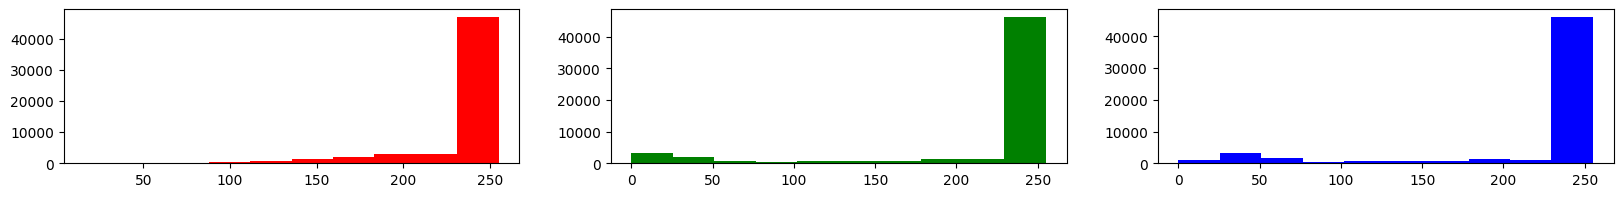

In [26]:
#동일하게 분포 나타내보기
query_image = np.array(query_image)
img_vector = query_image.reshape(1, -1, 3)
red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]
fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=10, color='r')
axs[1].hist(green_channel, bins=10, color='g')
axs[2].hist(blue_channel, bins=10, color='b')
plt.show()

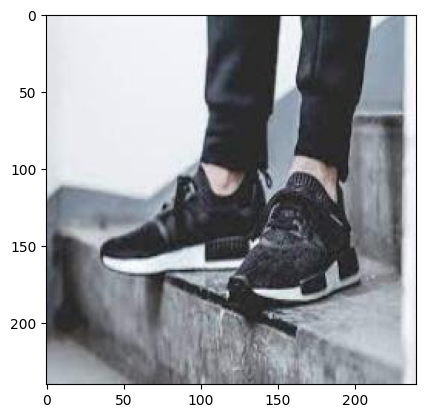

In [23]:
#마지막 이미지
query_image = dataset[141]['image']
plt.imshow(query_image)
plt.show()

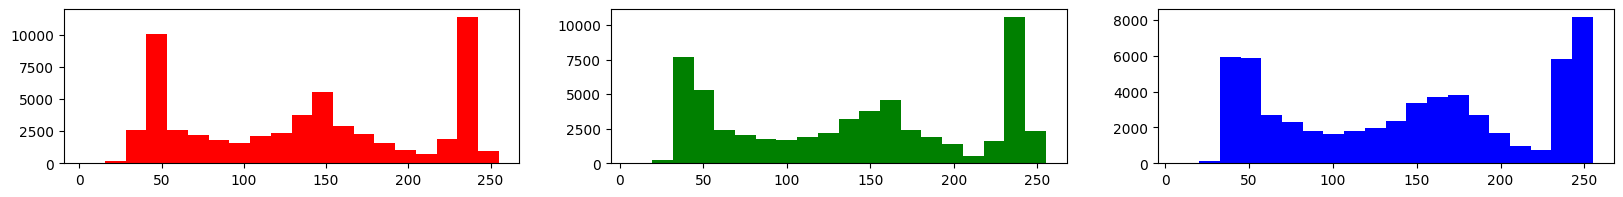

In [24]:

#마지막 이미지 분포 시각화
query_image = np.array(query_image)
img_vector = query_image.reshape(1, -1, 3)
red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]
fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=20, color='r')
axs[1].hist(green_channel, bins=20, color='g')
axs[2].hist(blue_channel, bins=20, color='b')
plt.show()